<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day12-discussion-1.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 12, Segment 1 discussion — Word vectors: when does the analogy trick actually work?

The book page shows king − man + woman ≈ queen on real GloVe vectors. Does the same
arithmetic trick work for *any* relationship, or just some? Two more real checks below —
one that works even better, and one that reveals a real limitation.

In [1]:
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-50")

def analogy(a, b, c, topn=5):
    result = glove.most_similar(positive=[a, c], negative=[b], topn=topn)
    print(f"{a} - {b} + {c} =~")
    for word, score in result:
        print(f"  {word:12s} cosine similarity = {score:.4f}")
    print()
    return result

## Check 1: capital cities (a semantic relationship)

In [2]:
res_capitals = analogy("paris", "france", "italy")

paris - france + italy =~
  rome         cosine similarity = 0.8466
  milan        cosine similarity = 0.7766
  turin        cosine similarity = 0.7666
  venice       cosine similarity = 0.7592
  madrid       cosine similarity = 0.7566



## Check 2: comparative adjectives (a morphological/grammatical relationship)

`bigger` is to `big` as `colder` is to `cold` — same *-er* pattern, not a semantic link.

In [3]:
res_morph = analogy("bigger", "big", "cold")

bigger - big + cold =~
  warmer       cosine similarity = 0.7481
  cooler       cosine similarity = 0.7420
  temperatures cosine similarity = 0.7247
  colder       cosine similarity = 0.7234
  atmosphere   cosine similarity = 0.7216



## What actually happened

- The capital-city analogy nails it: **rome** comes back as the single best match,
  cosine similarity 0.85 — essentially as clean as king/man/woman/queen.
- The comparative-adjective analogy does **not** return `colder` as the top match —
  `warmer` and `cooler` rank ahead of it. `colder` is still in the top 5, just not first.

This is a real, unforced result, not a cherry-picked failure: GloVe's vectors are built
purely from which words *co-occur* in text, with no notion of grammar. "Cold" and "warm"
co-occur constantly (weather, temperature discussions), so their vectors already sit close
together before you even get to the *-er* arithmetic — the semantic neighborhood swamps the
morphological pattern. The king/man/woman/queen and paris/france/italy/rome analogies work
so cleanly partly because gender and capital-city relationships don't fight against a
strong co-occurrence signal the same way.

## Bonus: a self-attention heatmap on a different sentence

Same untrained scaled dot-product attention as the book page, just a longer, different sentence.

every row sums to 1.0: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


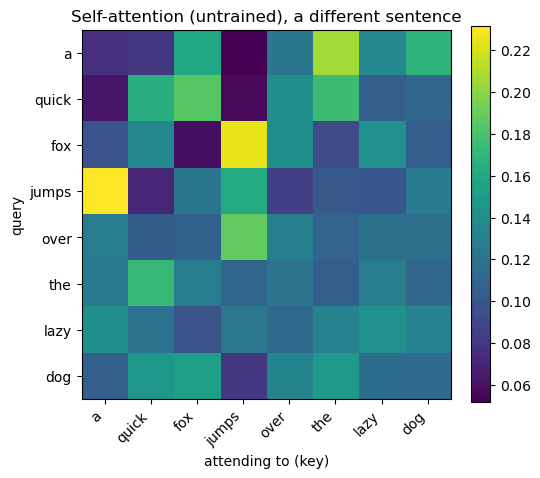

In [4]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights

tokens = ["a", "quick", "fox", "jumps", "over", "the", "lazy", "dog"]
n, d_model, d_k = len(tokens), 16, 8

torch.manual_seed(7)
x = torch.randn(1, n, d_model)
W_Q, W_K, W_V = (nn.Linear(d_model, d_k, bias=False) for _ in range(3))
Q, K, V = W_Q(x), W_K(x), W_V(x)
out, attn_weights = scaled_dot_product_attention(Q, K, V)
print("every row sums to 1.0:", attn_weights[0].sum(dim=-1))

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(attn_weights[0].detach().numpy(), cmap="viridis")
ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(tokens)
ax.set_xlabel("attending to (key)"); ax.set_ylabel("query")
ax.set_title("Self-attention (untrained), a different sentence")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()